In [48]:

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings("ignore")

# Project Overview

This notebook implements a full SVM-based data science project using a large health dataset.

- **Dataset**: `heart.csv` with 253,680 records and 22 features.
- **Goal**: Build a robust SVM classification model to predict `HeartDiseaseorAttack`.
- **Tasks covered**:
  - Exploratory Data Analysis (EDA)
  - Data cleaning and preparation
  - Dimensionality reduction using PCA
  - Model pipeline construction and hyperparameter tuning
  - Final model evaluation on held-out test data

> The dataset is sampled to 20,000 rows for faster notebook execution while preserving representative structure.

# Dataset Overview

The dataset contains 253,680 records and 22 features. We sample 20,000 rows for faster notebook execution while preserving the dataset structure and feature relationships.
The target variable is `HeartDiseaseorAttack`, and the features include health indicators, demographic data, and lifestyle variables.


In [49]:
# =========================================================
# LOAD DATA
# =========================================================

df = pd.read_csv("heart.csv")
df = df.sample(n=min(20000, len(df)), random_state=42).reset_index(drop=True)
print(df.shape)
print(df.head())



(20000, 22)
   HeartDiseaseorAttack  HighBP  HighChol  CholCheck   BMI  Smoker  Stroke  \
0                   0.0     0.0       0.0        1.0  21.0     0.0     0.0   
1                   0.0     1.0       1.0        1.0  28.0     0.0     0.0   
2                   0.0     0.0       0.0        1.0  24.0     0.0     0.0   
3                   0.0     0.0       0.0        1.0  27.0     1.0     0.0   
4                   0.0     0.0       1.0        1.0  31.0     1.0     0.0   

   Diabetes  PhysActivity  Fruits  ...  AnyHealthcare  NoDocbcCost  GenHlth  \
0       0.0           0.0     1.0  ...            1.0          0.0      3.0   
1       0.0           1.0     1.0  ...            1.0          0.0      3.0   
2       0.0           1.0     1.0  ...            1.0          0.0      1.0   
3       0.0           1.0     0.0  ...            1.0          0.0      2.0   
4       0.0           0.0     1.0  ...            1.0          1.0      4.0   

   MentHlth  PhysHlth  DiffWalk  Sex   Age  

# Data Cleaning

Inspect missing values and duplicate records. Avoid dropping rows unless necessary; document any data removal and retain as much information as possible for modeling.


In [50]:
# ==========================
# CLEANING
# ==========================
print(df.isnull().sum())

df = df.drop_duplicates()
print("After removing duplicates:", df.shape)


# ==========================
# TARGET SPLIT
# ==========================
target = "HeartDiseaseorAttack"   # غيّرها لو اسم العمود مختلف

X = df.drop(target, axis=1)
y = df[target]


HeartDiseaseorAttack    0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
Diabetes                0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64
After removing duplicates: (19562, 22)


# Exploratory Data Analysis (EDA)

Explore the target distribution, feature distributions, and feature relationships. Use each visualization once to uncover patterns, anomalies, and trends without repetition.


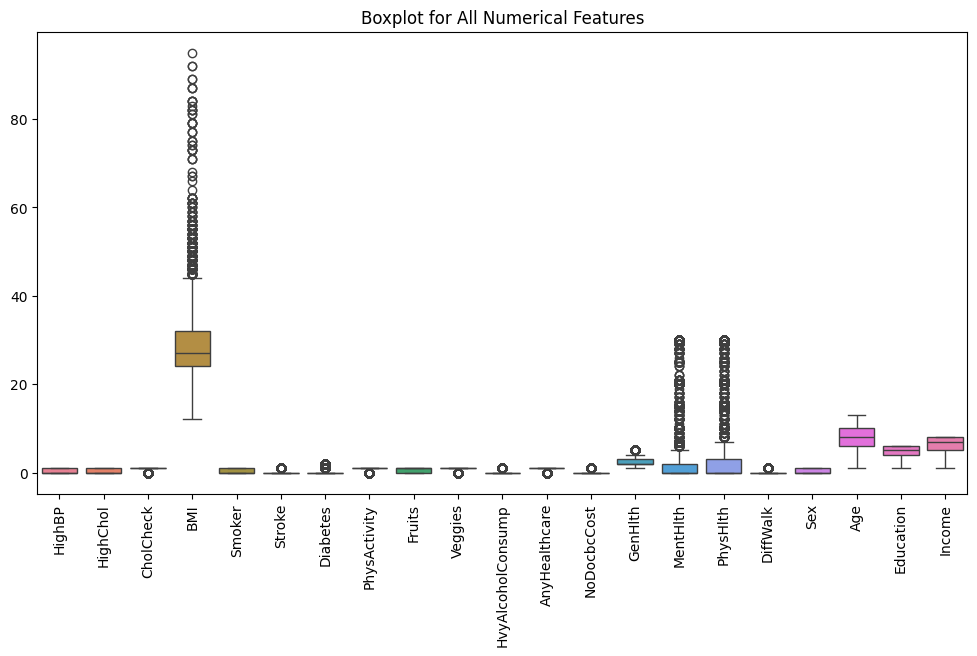

In [51]:

# ==========================
# BOX PLOT (ALL DATA IN ONE PLOT)
# ==========================

num_cols = X.select_dtypes(include=np.number).columns

plt.figure(figsize=(12,6))
sns.boxplot(data=X[num_cols])
plt.xticks(rotation=90)
plt.title("Boxplot for All Numerical Features")
plt.show()


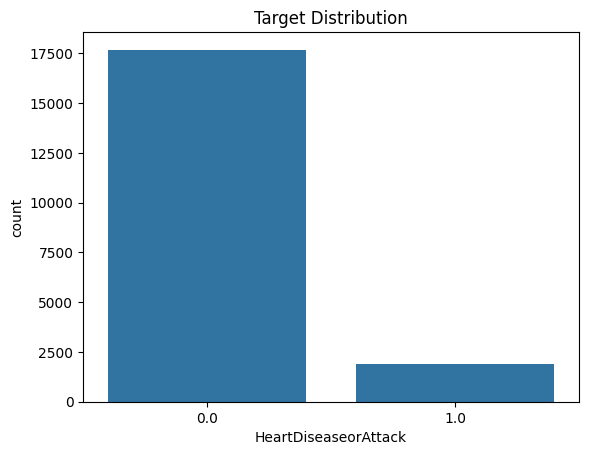

In [52]:
# ==========================
# EDA
# ==========================
plt.figure()
sns.countplot(x=y)
plt.title("Target Distribution")
plt.show()


# Data Balancing

Balance the dataset to avoid bias from class imbalance. Use under-sampling and over-sampling carefully to keep the class distribution even without dropping too much information.

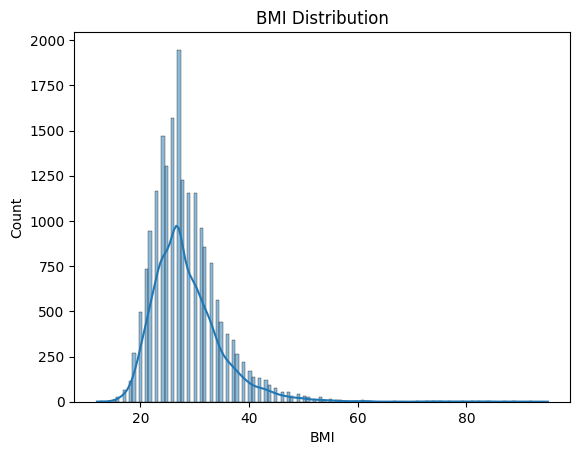

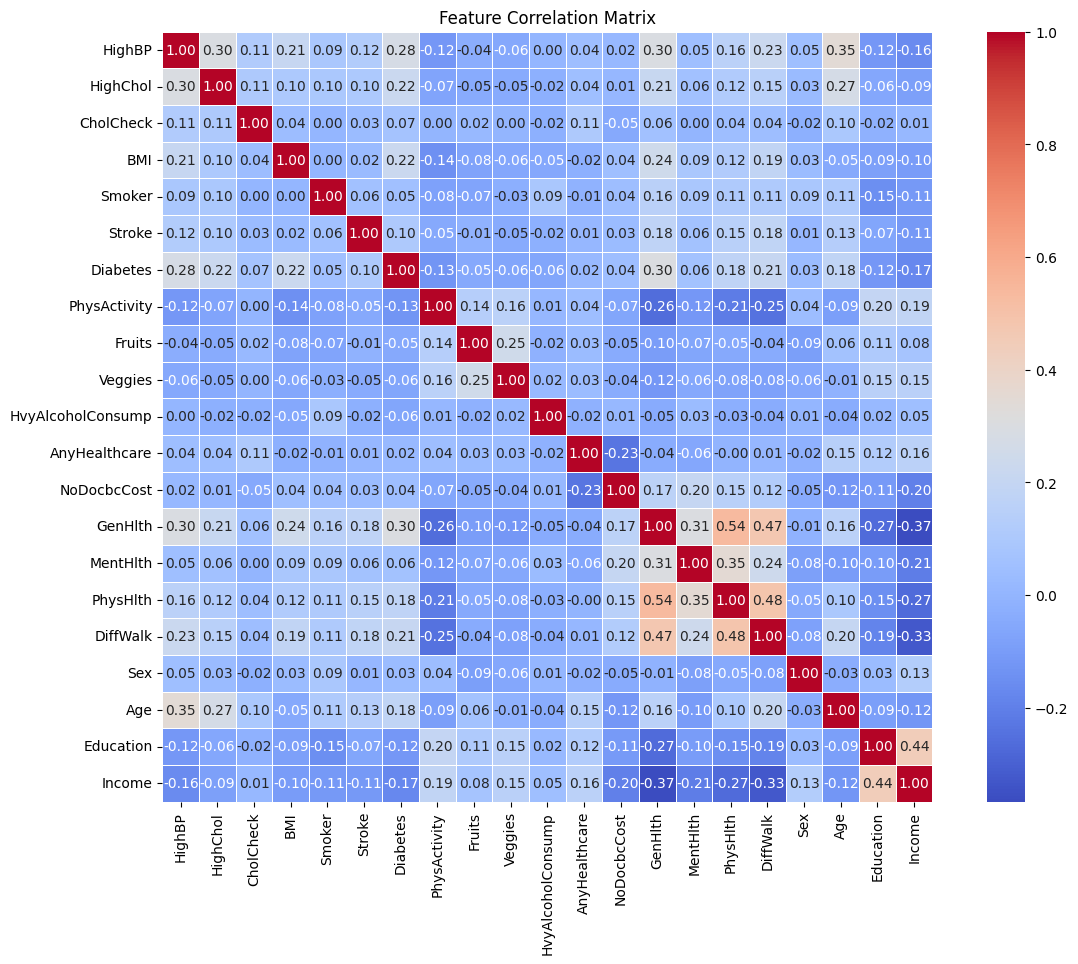

In [53]:

plt.figure()
sns.histplot(df["BMI"], kde=True)
plt.title("BMI Distribution")
plt.show()


# ==========================
# CORRELATION MATRIX (IMPROVED)
# ==========================

plt.figure(figsize=(14, 10))

corr = X.corr()

sns.heatmap(
    corr,
    annot=True,        # 👈 يطلع الأرقام
    fmt=".2f",         # 👈 رقمين بعد الكومه
    cmap="coolwarm",   # الألوان
    linewidths=0.5,    # فواصل بين الخلايا
    square=True        # شكل مرتب
)

plt.title("Feature Correlation Matrix")
plt.show()


# Train/Test Split and Modeling Pipeline

Split the data into training and testing sets before preprocessing to avoid data leakage. Then build a pipeline with scaling, PCA, and an SVM classifier.


In [54]:
# ==========================
# TRAIN TEST SPLIT (NO LEAKAGE)
# ==========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Before SMOTE class counts:")
print(y_train.value_counts())

smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

print("After SMOTE class counts:")
print(y_train.value_counts())


# ==========================
# PIPELINE (Scaling + PCA + SVM)
# ==========================
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=0.95)),
    ("svm", SVC())
])

Before SMOTE class counts:
HeartDiseaseorAttack
0.0    14143
1.0     1506
Name: count, dtype: int64
After SMOTE class counts:
HeartDiseaseorAttack
0.0    14143
1.0    14143
Name: count, dtype: int64


# Hyperparameter Tuning

Use grid search with cross-validation to tune the SVM hyperparameters. This helps produce a more robust model and improve generalization.


In [55]:
# ==========================
# HYPERPARAMETER TUNING + DIMENSIONALITY REDUCTION COMPARISON
# (Runs PCA, SelectKBest, and Correlation-based selection,
#  then picks the pipeline with highest test accuracy and prints details)
# ==========================
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import GridSearchCV

params = {
    "svm__C": [0.1, 1, 10],
    "svm__gamma": ["scale", 0.01],
    "svm__kernel": ["rbf"]
}

def run_grid(pipeline, params, X_tr, X_te, name):
    grid = GridSearchCV(pipeline, params, cv=3, n_jobs=1, verbose=1)
    grid.fit(X_tr, y_train)
    y_pred_local = grid.predict(X_te)
    acc = accuracy_score(y_test, y_pred_local)
    print('\n=== {} ==='.format(name))
    print('Best params:', grid.best_params_)
    print('Test accuracy: {:.4f}'.format(acc))
    print(classification_report(y_test, y_pred_local))
    return grid.best_estimator_, acc, y_pred_local

# 1) PCA pipeline (baseline)
pipeline_pca = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=0.95)),
    ("svm", SVC())
])
best_pca, acc_pca, pred_pca = run_grid(pipeline_pca, params, X_train, X_test, 'PCA')

# 2) SelectKBest pipeline
k = min(10, X_train.shape[1])
pipeline_kbest = Pipeline([
    ("scaler", StandardScaler()),
    ("kbest", SelectKBest(f_classif, k=k)),
    ("svm", SVC())
])
best_kbest, acc_kbest, pred_kbest = run_grid(pipeline_kbest, params, X_train, X_test, f'SelectKBest(k={k})')

# 3) Correlation-based dropping + SelectKBest
corr = X_train.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.95)]
print('\nCorrelation-based drop (threshold=0.95):', to_drop)

X_train_corr = X_train.drop(columns=to_drop)
X_test_corr = X_test.drop(columns=[c for c in to_drop if c in X_test.columns])

k2 = min(10, X_train_corr.shape[1])
pipeline_corr = Pipeline([
    ("scaler", StandardScaler()),
    ("kbest", SelectKBest(f_classif, k=k2)),
    ("svm", SVC())
])
best_corr, acc_corr, pred_corr = run_grid(pipeline_corr, params, X_train_corr, X_test_corr, f'CorrDrop+KBest(k={k2})')

# Choose best method
results = {"pca": acc_pca, "kbest": acc_kbest, "corr": acc_corr}
best_method = max(results, key=results.get)
print('\nComparison results:', results)
print('Selected best method:', best_method, 'with accuracy', results[best_method])

# Print detailed info about chosen method
if best_method == 'pca':
    best_model = best_pca
    y_pred = pred_pca
    pca_step = best_model.named_steps.get('pca') if hasattr(best_model, 'named_steps') else None
    if pca_step is not None:
        n_comp = getattr(pca_step, 'n_components_', None)
        var_sum = getattr(pca_step, 'explained_variance_ratio_', None)
        print('PCA n_components:', n_comp)
        if var_sum is not None:
            print('Explained variance ratio sum:', var_sum.sum())
elif best_method == 'kbest':
    best_model = best_kbest
    y_pred = pred_kbest
    kbest_step = best_model.named_steps.get('kbest') if hasattr(best_model, 'named_steps') else None
    if kbest_step is not None:
        selected = X_train.columns[kbest_step.get_support()]
        print('SelectKBest selected features:', list(selected))
else:
    best_model = best_corr
    y_pred = pred_corr
    print('Dropped correlated features:', to_drop)
    kbest_step = best_model.named_steps.get('kbest') if hasattr(best_model, 'named_steps') else None
    if kbest_step is not None:
        selected = X_train_corr.columns[kbest_step.get_support()]
        print('Selected features after correlation drop:', list(selected))

# best_model and y_pred will be used by the evaluation cell that follows


Fitting 3 folds for each of 6 candidates, totalling 18 fits

=== PCA ===
Best params: {'svm__C': 10, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}
Test accuracy: 0.8789
              precision    recall  f1-score   support

         0.0       0.92      0.94      0.93      3536
         1.0       0.34      0.26      0.29       377

    accuracy                           0.88      3913
   macro avg       0.63      0.60      0.61      3913
weighted avg       0.87      0.88      0.87      3913

Fitting 3 folds for each of 6 candidates, totalling 18 fits

=== SelectKBest(k=10) ===
Best params: {'svm__C': 10, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}
Test accuracy: 0.8582
              precision    recall  f1-score   support

         0.0       0.93      0.92      0.92      3536
         1.0       0.28      0.31      0.30       377

    accuracy                           0.86      3913
   macro avg       0.60      0.61      0.61      3913
weighted avg       0.86      0.86      0.86      39

# Model Evaluation

Evaluate the final SVM model on the held-out test set using accuracy, a classification report, and a confusion matrix. This measures performance on unseen data.



Selected best method: pca with accuracy 0.8789

Accuracy: 0.8788653207257858

Classification Report:

              precision    recall  f1-score   support

         0.0       0.92      0.94      0.93      3536
         1.0       0.34      0.26      0.29       377

    accuracy                           0.88      3913
   macro avg       0.63      0.60      0.61      3913
weighted avg       0.87      0.88      0.87      3913



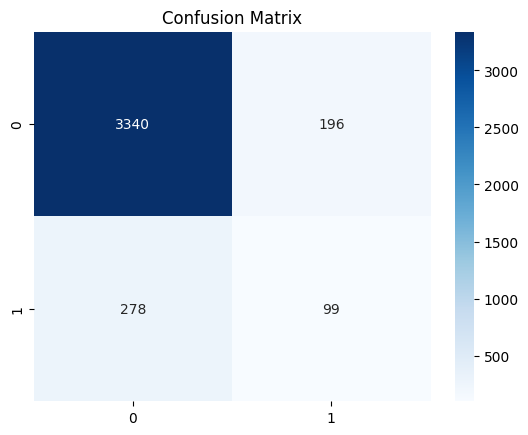


✓ Model saved with 21 features
Features: ['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'Diabetes', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']


In [56]:
# ==========================
# EVALUATION
# ==========================
print(f"\nSelected best method: {best_method} with accuracy {results[best_method]:.4f}")
print("\nAccuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


# ==========================
# CONFUSION MATRIX
# ==========================
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.show()


# ==========================
# SAVE MODEL (BONUS FOR DEPLOYMENT)
# ==========================
import joblib
import pickle

# Save model
joblib.dump(best_model, "svm_model.pkl")

# Also save feature names and column info
model_metadata = {
    'feature_names': list(X_train.columns),
    'n_features': X_train.shape[1],
    'model': best_model
}

with open('model_metadata.pkl', 'wb') as f:
    pickle.dump(model_metadata, f)

print(f"\n✓ Model saved with {X_train.shape[1]} features")
print(f"Features: {list(X_train.columns)}")
